<div style="position: relative; width: 100%;">

<div style="text-align:center;">
    
# 🌌 ROPE: Reduced-Order Probabilistic Emulator  
### Latent-Space Forecasting of Thermospheric Density with Uncertainty  

</div>

<div style="position: absolute; right: 0; top: 0; font-size: 14px; text-align:right;">
    Anirudh Tapedia<br>
    West Virginia University
</div>

</div>


> **ROPE** is a reduced-order, probabilistic emulator of the TIE-GCM thermosphere.  
> It forecasts global density fields in a low-dimensional latent space using various Nueral Network models and ensemble meta-learning, and provides calibrated uncertainty  



In [1]:
from rope import ROPE
from interpolator import DensityInterpolator


2026-01-20 21:46:30.265261: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
# Initialize ROPE model (runs on GPU if available)
rope = ROPE(device="cuda") 

# Generate a 120 hour global density grid forecast starting from a given time
res  = rope.run("2024-03-02 04:00:00", horizon=120)


q = DensityInterpolator(res)
# print(q.bounds()) # Prints the max-min bounds
out1 = q.query("2024-03-05 05:30:00", lst=10.5, lat=25.0, alt_km=400.0)
out2 = q.query("2024-03-05 00:30:00", lst=10.5, lat=25.0, alt_km=400.0)

In [9]:
out1

{'datetime_requested': Timestamp('2024-03-05 05:30:00'),
 'datetime_used': Timestamp('2024-03-05 06:00:00'),
 'density': 7.19374169544748e-12,
 't_index': 74,
 'time_mode': 'hold_next_hour',
 'sigma': 1.3338629245335994e-12}

In [5]:
from eval_satellite import compare_against_satellite

Loaded SWARM 2024-05: 89190 rows


  0%|          | 0/86130 [00:00<?, ?it/s]

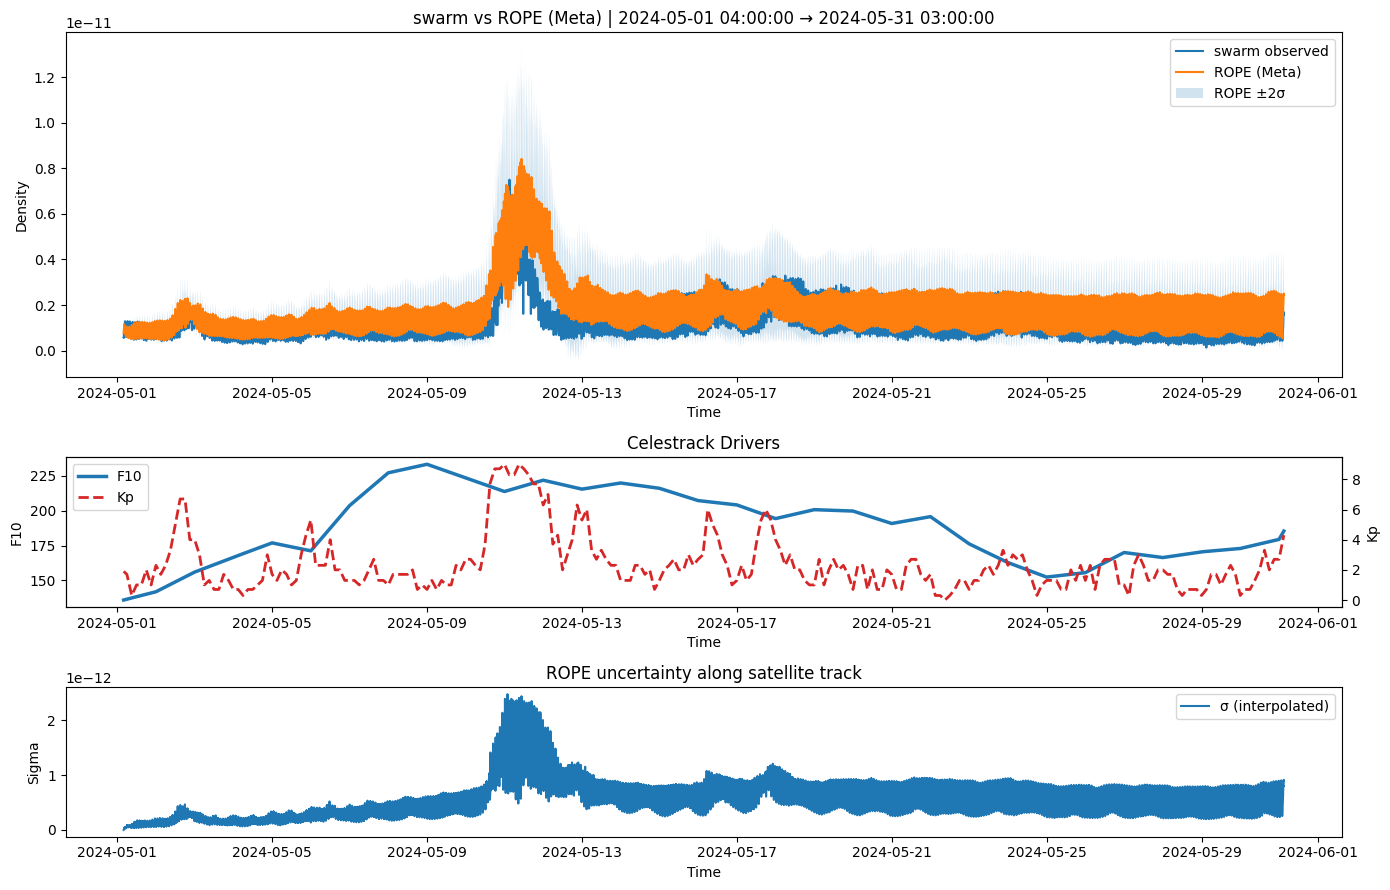

In [6]:
df_eval = compare_against_satellite(
    satellite_name="swarm",
    start_time="2024-05-01 04:00:00",
    horizon=720,
    device="cuda"
)
